This notebook will be used to build your simulation.

In [1]:
import sys
sys.path.append('..')
sys.path.append('../Modules')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(os.getcwd())
if 'notebook' in os.getcwd():
    # os.chdir("../scripts") # go from Neural-Modeling/notebooks to Neural-Modeling/scripts, where simulation outputs will be generated to. (maybe a separate folder could be used...)
    os.chdir("../simulations") # go to output folder
    print(os.getcwd())

/home/drfrbc/Neural-Modeling/notebooks
/home/drfrbc/Neural-Modeling/simulations


## User Specifications -  parameters, simulation folder

In [2]:
from Modules.constants import HayParameters
import datetime
import pickle
from neuron import h

from Modules.simulation_slurm import Simulator

from scripts.gen_param_list_advanced import sim_type_params_all

# this is a quick example, but the advanced generation of parameter sets and titles for parametric study is in scripts/gen_param_list_advanced.py

sim_set_title= "baseline_clusters_dec_radius"# "name_of_simulation_set"
sim_titles =  ["complex"] #["name_of_simulation1_within_set"] # for multiple: ["description_of_simulation1_within_set", "description_of_simulation2_within_set"],
sim_type = 'sta' # select simulation type

# import predefined clusters. stored in Modules/clusters.py instead of default from Modules/constants.py.
from Modules.clusters import exc_clustering#, inh_clustering 

parameter_sets = [HayParameters(sim_title,
                                all_synapses_off=True, 
                                exc_clustering=exc_clustering,  # just use one big exc cluster for now.
                                # inh_clustering=inh_clustering,
                                **sim_type_params_all[sim_type],
                                )
                                for sim_title in sim_titles] # no variation between simulations with this code snippet
# initialize with all_synapses_off for saving segments.csv without building synapses. # TODO: adjust saving of segments.csv to not require this. Also requires removing previous built-in synapse building implementation from cell_builder.py.

simulator = Simulator(
                        sim_set_title = sim_set_title,
                        sim_titles = sim_titles,
                        parameter_sets = parameter_sets)

# create simulation folders and save parameters in them
simulator.create_simulation_folders()

# @TODO: modularize gen_param_list_advanced.py so it can optionally be used here.
# @TODO: compile modfiles once in Simulator.__init__ if not already compiled. would need to specify them.
# @TODO: implement running accompanying functions on all sims within the simulator object in parallel or loop.

--No graphics will be displayed.


Mod files loaded successfully


In [3]:
sim_type_params_all[sim_type]

{'h_tstop': 5000,
 'merge_synapses': False,
 'record_ecp': False,
 'record_all_channels': True,
 'record_all_synapses': True}

In [4]:
simulator.sims_dir

'2025-06-06-14-01-baseline_clusters_dec_radius'

In [5]:
sim_dir = os.path.join(simulator.sims_dir, simulator.sim_titles[0]) # choose first simulation directory for the example.
os.path.abspath(sim_dir) # for copying over

'/home/drfrbc/Neural-Modeling/simulations/2025-06-06-14-01-baseline_clusters_dec_radius/complex'

## Generate segments.csv

In [6]:
from Modules.segments_file import generate_segments_csv

simulator.run_on_all_sims(simulator.sims_dir, generate_segments_csv) # generate the segments csv for each simulation

Removing duplicate coordinate at index 1 in section L5PCtemplate[0].apic[0]
getting segments of types: ['distal_basal' 'nexus' 'oblique' 'perisomatic' 'trunk' 'tuft'] for synapses


In [7]:
# read segments.csv file
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))
seg_data.head() # show the first few rows of the segments data

,section,idx_in_section_type,seg_half_seg_RA,L,length,seg,pseg,Section_L,Section_diam,Distance,...,pc_2,p1_0,p1_1,p1_2,r,dl_0,dl_1,dl_2,seg_id,sec_type_precise
0,soma,0,0.081276,23.169408,23.169408,L5PCtemplate[0].soma[0](0.5),None,23.169408,13.471518,0.000000,...,-50.250000,57.287731,19.065830,-50.250000,6.735759,23.124348,1.444304,0.000000,0,soma
1,dend,0,2.647135,4.840176,4.840176,L5PCtemplate[0].dend[0](0.1),L5PCtemplate[0].soma[0](0.5),24.200878,1.170000,2.420088,...,-50.027254,61.001504,21.408927,-49.444755,0.539452,4.591504,1.178928,0.805245,1,perisomatic
2,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.3),L5PCtemplate[0].dend[0](0.1),24.200878,1.170000,7.260263,...,-50.557475,64.964606,21.737526,-51.687077,0.585000,3.963102,0.328599,-2.242322,2,perisomatic
3,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.5),L5PCtemplate[0].dend[0](0.3),24.200878,1.170000,12.100439,...,-51.991813,68.301396,20.356904,-50.119401,0.585000,3.336790,-1.380622,1.567676,3,perisomatic
4,dend,0,2.250969,4.840176,4.840176,L5PCtemplate[0].dend[0](0.7),L5PCtemplate[0].dend[0](0.5),24.200878,1.170000,16.940615,...,-48.246989,70.726764,18.807201,-46.252588,0.585000,2.425368,-1.549704,3.866813,4,perisomatic


In [8]:
from Modules import analysis
parameters = analysis.DataReader.load_parameters(sim_dir) # load parameters
# parameters # print parameters

## Visualize Cell and automated classification of dendritic types

In [9]:
# # for visualizing the cell and automated sec_type_precise generation
from Modules.plot_morphology import plot_morphology_with_highlighted_sec_type, plot_morphology_with_y_range
import Modules.analysis as analysis

# In the event that automation is not successful, we can deal with overlapping precise section types using the `overlaps` dictionary from the segments file.
# ### OVERLAPPING PRECISE SEC TYPE LABELS TODO: (pull overlaps from generate_segments_csv if there are overlaps)
# # overlapping_seg_ids = [i for i,j in overlaps.items()]

################################
# highlight multiple section types (Figure for AST)
################################

# # Option 1: highlight multiple section types with different colors
# from Modules.plot_morphology import plot_morphology_with_highlighted_sec_types
# sec_types = ['perisomatic', 'distal_basal', 'distal_apical']
# fig, ax = plot_morphology_with_highlighted_sec_types(sec_types, seg_data, figsize=(10, 6))

# # Option 2: highlight multiple section types with the same color
# os.makedirs(os.path.join(sim_dir, "morphology"), exist_ok=True)
# for sec_type in parameters.inh_syn_properties.keys(): # get list of section types
#     print(f"Plotting {sec_type}:")
#     fig, ax = plot_morphology_with_highlighted_sec_type(sec_type, seg_data)
#     ax.set_title(sec_type) # TODO: not working for some reason
#     fig.tight_layout()
#     plt.show()
#     fig.savefig(os.path.join(sim_dir, "morphology", f"{sec_type}.png"))

################################
# highlight y_range in morphology (high Ca2+)
################################
# # Custom y-range (default is Ca2+ hot spot from hay et al. 2011)
# fig, ax = plot_morphology_with_y_range(seg_data, y_min=685, y_max=885) # can save to file with argument save_path='path/to/save.png'

################################
######### plot nexus ###########
################################
# sec_type = 'nexus'
# fig, ax = plot_morphology_with_highlighted_sec_type(sec_type, seg_data)
# ax.set_title(sec_type) # TODO: not working for some reason
# fig.tight_layout()
# plt.show()
# # fig.savefig(os.path.join(sim_dir, "morphology", f"{sec_type}.png"))

## Generate Synapses.csv

In [10]:
# generate synapse objects abstractly. store info in csv.
from Modules.synapses_file import PreSimSynapseGenerator

# create PreSimSynapseGenerator instance and generate synapse locations, weights, etc.
# everything except presynaptic spike trains.
pssg = PreSimSynapseGenerator(sim_dir)
pssg.generate_synapse_locations()
pssg.synapses.to_csv(os.path.join(sim_dir, "synapses.csv"), index=False)

NEURON: The user defined name already exists: AMPA_NMDA
 near line 0
 {gCa_HVAbar_Ca_HVA(1.0000000000) = 0.0000555000}
                                                 ^
        nrn_load_dll("../scripts...")


In [11]:
# # view synapses from synapses csv
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
synapses.head() # show the first few lines of synapses

# tooltip: P_0 is release probability, initW is the initial weight multiplier,
# gbar_ampa and gbar_nmda are the excitatory synapse conductances,
# gbar_gaba is the inhibitory synapse conductance
# seg_id is the segment ID where the synapse is located

,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba
0,exc_tuft_0,pyr2pyr,0.354387,1.548931,PN2PN,2023,0.00159,0.001868,NaN
1,exc_tuft_1,pyr2pyr,0.686850,1.683359,PN2PN,1638,0.00159,0.001868,NaN
2,exc_tuft_2,pyr2pyr,0.379372,1.416896,PN2PN,2140,0.00159,0.001868,NaN
3,exc_tuft_3,pyr2pyr,0.000000,1.761343,PN2PN,2085,0.00159,0.001868,NaN
4,exc_tuft_4,pyr2pyr,0.990291,1.251326,PN2PN,1720,0.00159,0.001868,NaN


## Add spike trains to synapses.csv

In [12]:
# adds column spike_train according to parameters.
pssg.generate_spike_trains_for_synapses()
# simulator.run_on_all_sims(simulator.sims_dir, use_pssg, pssg_function_name= 'generate_spike_trains_for_synapses') #TODO: fix

Coordinates of synapses in this section and synapse type: [[ 17.88754613  -1.75250603 -17.98471441]
 [ 15.94639621  -2.73113764 -13.92019131]]
Coordinates of presynaptic cell center: [0 0 0], radius: 5.0


In [13]:
exc_clustering

{'tuft': {'functional_groups': [{'center': (-54.61, 983.56, -62.58),
    'radius': 124.4575,
    'presynaptic_cells': [{'center': (-54.61, 983.56, -62.58),
      'radius': 124.4575,
      'name': 'PC_2016',
      'max_synapses': 10}]},
   {'center': (12.45, 1030.49, -20.27),
    'radius': 90.5925,
    'presynaptic_cells': [{'center': (12.45, 1030.49, -20.27),
      'radius': 90.5925,
      'name': 'PC_2179',
      'max_synapses': 10}]},
   {'center': (-35.7, 1101.04, -89.13),
    'radius': 46.955,
    'presynaptic_cells': [{'center': (-35.7, 1101.04, -89.13),
      'radius': 46.955,
      'name': 'PC_2086',
      'max_synapses': 10}]},
   {'center': (-63.82, 953.36, -9.27),
    'radius': 129.8275,
    'presynaptic_cells': [{'center': (-63.82, 953.36, -9.27),
      'radius': 129.8275,
      'name': 'PC_1706',
      'max_synapses': 10}]},
   {'center': (21.21, 1071.59, -16.96),
    'radius': 72.2025,
    'presynaptic_cells': [{'center': (21.21, 1071.59, -16.96),
      'radius': 72.2025,


In [14]:
# view updated synapses now having spike_train column
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
synapses.head() # show the csv

,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,spike_train,pc_mean_firing_rate,functional_group,presynaptic_cell
0,exc_tuft_0,pyr2pyr,0.354387,1.548931,PN2PN,2023,0.00159,0.001868,NaN,[2012 2533 3430 4282 4662],1.249588,6.0,0.0
1,exc_tuft_1,pyr2pyr,0.686850,1.683359,PN2PN,1638,0.00159,0.001868,NaN,[ 69 87 242 407 426 495 655 678 788 ...,6.068628,3.0,0.0
2,exc_tuft_2,pyr2pyr,0.379372,1.416896,PN2PN,2140,0.00159,0.001868,NaN,[ 18 803 1138 1268 1325 1631 1680 1729 2030 ...,3.960701,4.0,0.0
3,exc_tuft_3,pyr2pyr,0.000000,1.761343,PN2PN,2085,0.00159,0.001868,NaN,[ 2 20 143 1038 1060 1243 1319 3270 3970 ...,2.521061,-1.0,-1.0
4,exc_tuft_4,pyr2pyr,0.990291,1.251326,PN2PN,1720,0.00159,0.001868,NaN,[ 13 23 149 253 266 302 315 345 360 ...,10.603298,9.0,0.0


## Analyze Designed Synapses

### Visualize Cluster locations

In [15]:
parameters.exc_clustering # view the setup

{'tuft': {'functional_groups': [{'center': (-54.61, 983.56, -62.58),
    'radius': 124.4575,
    'presynaptic_cells': [{'center': (-54.61, 983.56, -62.58),
      'radius': 124.4575,
      'name': 'PC_2016',
      'max_synapses': 10}]},
   {'center': (12.45, 1030.49, -20.27),
    'radius': 90.5925,
    'presynaptic_cells': [{'center': (12.45, 1030.49, -20.27),
      'radius': 90.5925,
      'name': 'PC_2179',
      'max_synapses': 10}]},
   {'center': (-35.7, 1101.04, -89.13),
    'radius': 46.955,
    'presynaptic_cells': [{'center': (-35.7, 1101.04, -89.13),
      'radius': 46.955,
      'name': 'PC_2086',
      'max_synapses': 10}]},
   {'center': (-63.82, 953.36, -9.27),
    'radius': 129.8275,
    'presynaptic_cells': [{'center': (-63.82, 953.36, -9.27),
      'radius': 129.8275,
      'name': 'PC_1706',
      'max_synapses': 10}]},
   {'center': (21.21, 1071.59, -16.96),
    'radius': 72.2025,
    'presynaptic_cells': [{'center': (21.21, 1071.59, -16.96),
      'radius': 72.2025,


In [16]:
parameters.inh_clustering # view the setup

{'perisomatic': {'functional_groups': [{'center': (0, 0, 0),
    'radius': 30.0,
    'presynaptic_cells': [{'center': (0, 0, 0),
      'radius': 5.0,
      'name': 'PC1',
      'max_synapses': 10}]}]}}

/home/drfrbc/Neural-Modeling/notebooks/../Modules/plot_morphology.py:235: UserWarning: No synapses found in presynaptic cell 0 of functional group 0 in section type perisomatic
  warnings.warn(f"No synapses found in presynaptic cell {pc_idx} of functional group {fg_idx} in section type {sec_type}")


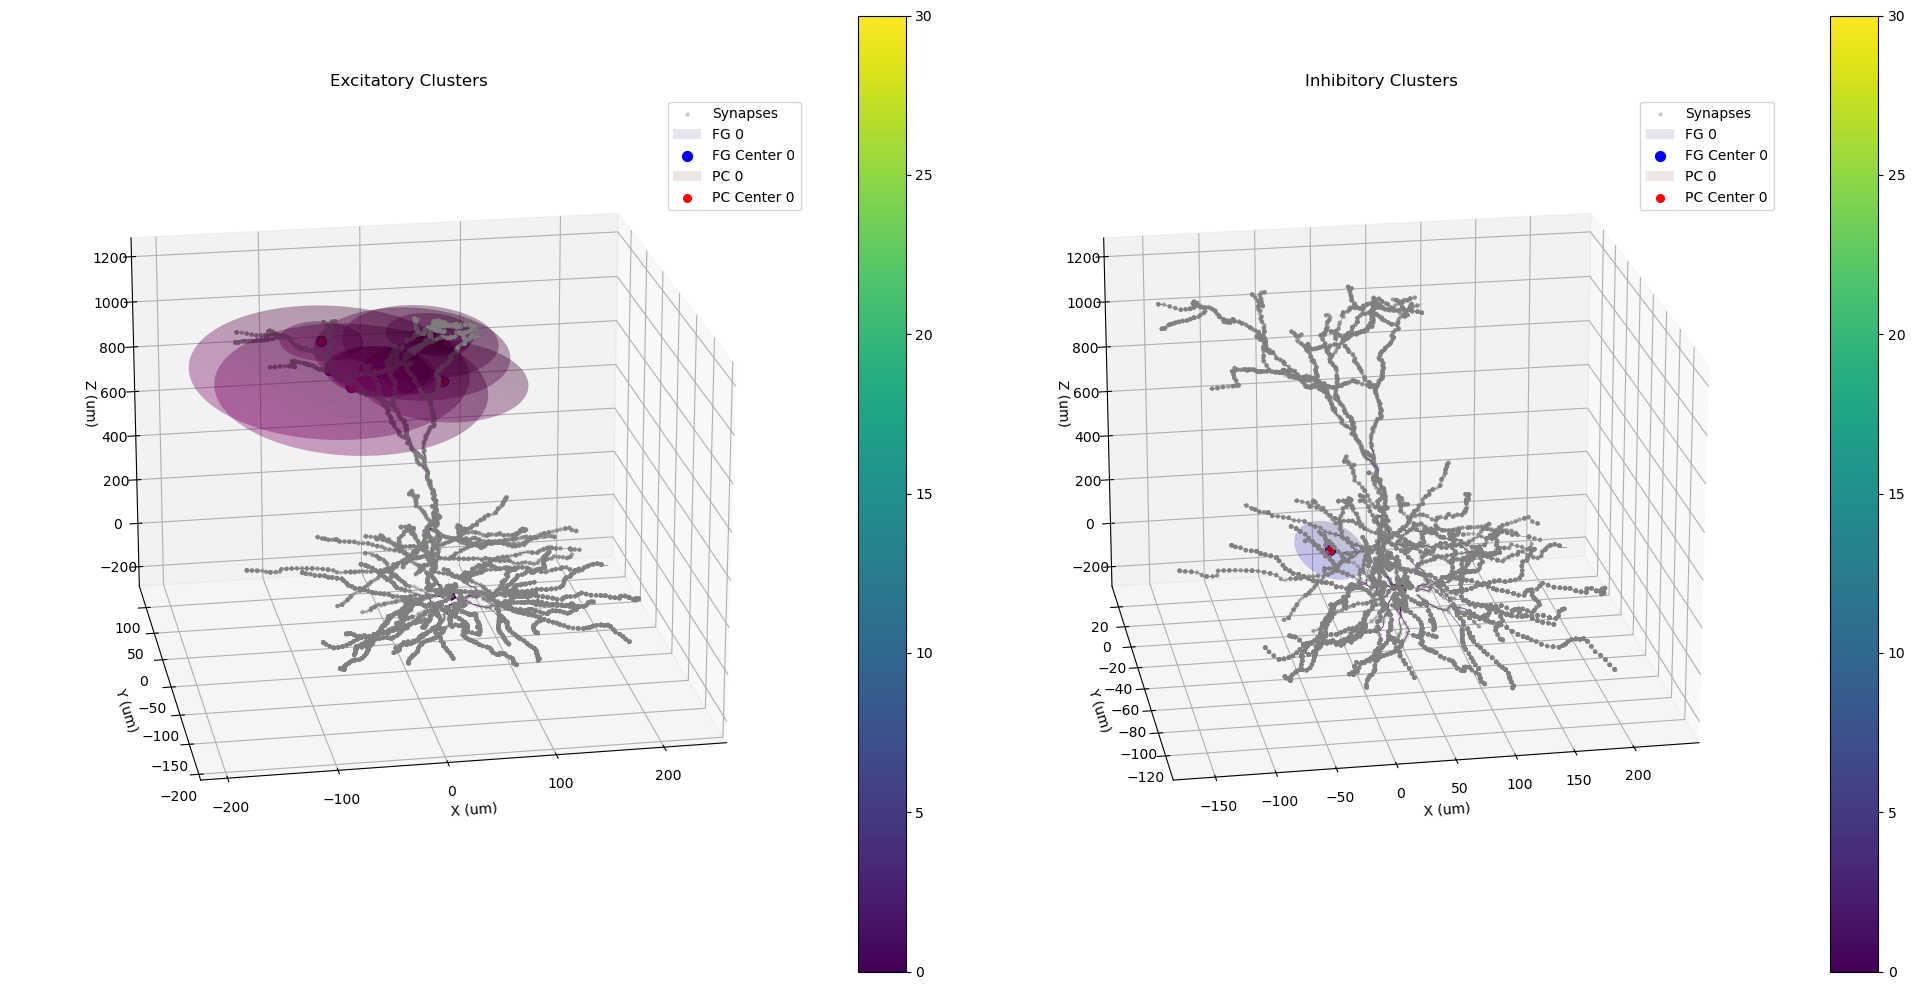

In [17]:
# TODO: move to synapse_analysis.py
# Import necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Modules.plot_morphology import plot_clusters
import os
import pickle

# Load parameters and data
# sim_dir = "path_to_your_simulation_directory"  # Replace with your actual simulation directory
with open(os.path.join(sim_dir, "parameters.pickle"), 'rb') as file:
    parameters = pickle.load(file)

# Load segment data
seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))

# # Load synapse data if available
synapses_with_seg_info = synapses.merge( # TODO: alternative could be used to save memory.
    seg_data, 
    on='seg_id', 
    how='left',               # carry along all synapses even if a seg_id is missing
    suffixes=('','_seg')      # if both synapses and segments have a column with the same name, suffix the seg col with _seg
)

columns = ['pc_0', 'pc_1', 'pc_2']

# get the coordinates of the synapses
synapse_coords = synapses_with_seg_info[columns].values

# Create figure with multiple subplots for different section types
fig = plt.figure(figsize=(20, 10))

# Plot excitatory clusters
ax1 = fig.add_subplot(121, projection='3d')
plot_clusters(
    seg_data=seg_data,
    clustering_config=parameters.exc_clustering,
    synapse_coords=synapse_coords,
    ax=ax1,
    elevation=20,
    azimuth=-100,
    title='Excitatory Clusters'
)

# Plot inhibitory clusters
ax2 = fig.add_subplot(122, projection='3d')
plot_clusters(
    seg_data=seg_data,
    clustering_config=parameters.inh_clustering,
    synapse_coords=synapse_coords,
    ax=ax2,
    elevation=20,
    azimuth=-100,
    title='Inhibitory Clusters'
)

plt.tight_layout()
plt.show()

# # Optional: Plot individual section types separately
# # exc clusters
# for sec_type in parameters.exc_clustering.keys(): #exc clusters
#     fig = plt.figure(figsize=(10, 10))
#     ax = fig.add_subplot(111, projection='3d')
#     plot_clusters(
#         seg_data=seg_data,
#         clustering_config={sec_type: parameters.exc_clustering[sec_type]},
#         synapse_coords=synapse_coords,
#         ax=ax,
#         elevation=20,
#         azimuth=-100,
#         title=f'Excitatory Clusters - {sec_type}'
#     )
#     plt.tight_layout()
#     plt.show()

# # inh clusters
# for sec_type in parameters.inh_clustering.keys(): # inh clusters
#     fig = plt.figure(figsize=(10, 10))
#     ax = fig.add_subplot(111, projection='3d')
#     plot_clusters(
#         seg_data=seg_data,
#         clustering_config={sec_type: parameters.inh_clustering[sec_type]},
#         synapse_coords=synapse_coords,
#         ax=ax,
#         elevation=20,
#         azimuth=-100,
#         title=f'Inhibitory Clusters - {sec_type}'
#     )
#     plt.tight_layout()
#     plt.show()

In [18]:
# check how many background synapses there are and how many are in functional groups and presynaptic cells
synapses = pd.read_csv(os.path.join(sim_dir, 'synapses.csv'))
count = len(synapses[(synapses['presynaptic_cell'] != -1) & (synapses['functional_group'] != -1)]) # count the number of synapses with functional groups other than -1 and presynaptic cell other than -1
print(f"Total number of synapses: {len(synapses)}")
print(f"Synapses assigned to PCs and FGs: {count}")
print(f"Number of background synapses: {len(synapses[(synapses['presynaptic_cell'] == -1) & (synapses['functional_group'] == -1)])}")

Total number of synapses: 18943
Synapses assigned to PCs and FGs: 2099
Number of background synapses: 16842


In [19]:
len(synapses[(synapses['presynaptic_cell'] != -1)])

2099

## Further synapse design analysis (Spike raster, etc.) (To be finished)

In [20]:
from Modules.synapse_analysis import SynapseAnalyzer

# Initialize the analyzer with your simulation directory
analyzer = SynapseAnalyzer(sim_dir)
analyzer.add_segment_data()

In [21]:
# Get statistics for a specific functional group
stats = analyzer.analyze_cluster_statistics(
    functional_group_id=0,
    synapse_type='exc'
)
print(f"stats for exc cluster group {0}: {stats}")

stats for exc cluster group 0: {'total_synapses': 27, 'mean_firing_rate': 6.028710245364629, 'std_firing_rate': 9.050976241643627e-16, 'mean_weight': 1.548003010953386, 'std_weight': 0.1517601022228156, 'mean_isi': 6.910128388017118, 'std_isi': 47.132697884023116, 'total_spikes': 702}


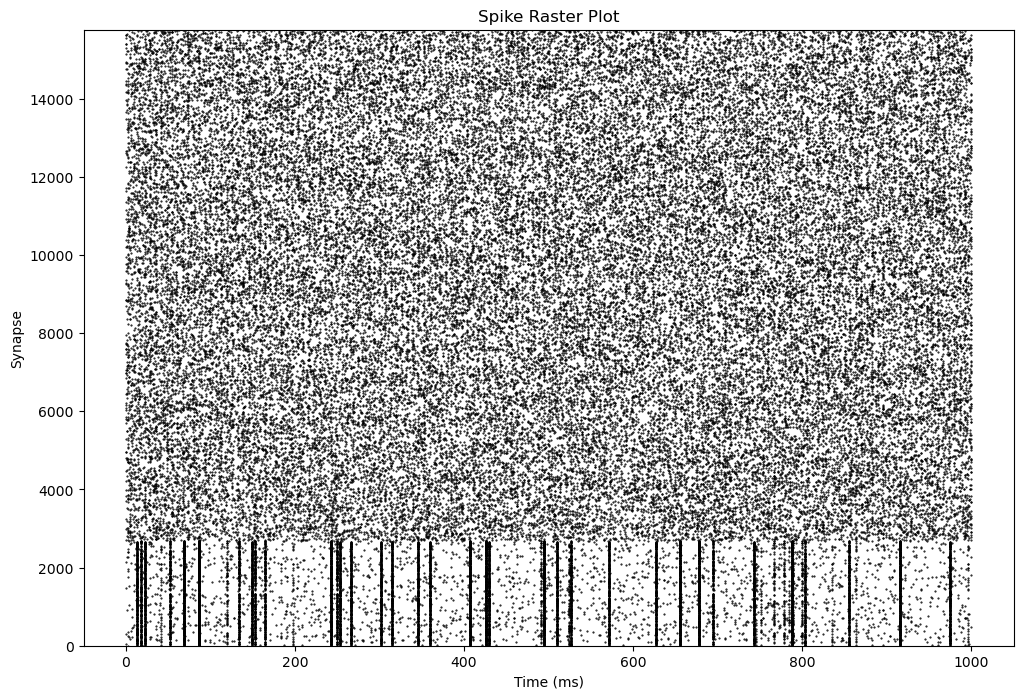

In [22]:
# Generate a spike raster plot for excitatory synapses
analyzer.plot_spike_raster(
    synapse_types=['exc'],
    time_window=(0, 1000),  # First second of simulation
    save_path=os.path.join(sim_dir, 'spike_raster.png')
)

In [23]:
synapses

,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,spike_train,pc_mean_firing_rate,functional_group,presynaptic_cell
0,exc_tuft_0,pyr2pyr,0.354387,1.548931,PN2PN,2023,0.00159,0.001868,NaN,[2012 2533 3430 4282 4662],1.249588,6.0,0.0
1,exc_tuft_1,pyr2pyr,0.686850,1.683359,PN2PN,1638,0.00159,0.001868,NaN,[ 69 87 242 407 426 495 655 678 788 ...,6.068628,3.0,0.0
2,exc_tuft_2,pyr2pyr,0.379372,1.416896,PN2PN,2140,0.00159,0.001868,NaN,[ 18 803 1138 1268 1325 1631 1680 1729 2030 ...,3.960701,4.0,0.0
3,exc_tuft_3,pyr2pyr,0.000000,1.761343,PN2PN,2085,0.00159,0.001868,NaN,[ 2 20 143 1038 1060 1243 1319 3270 3970 ...,2.521061,-1.0,-1.0
4,exc_tuft_4,pyr2pyr,0.990291,1.251326,PN2PN,1720,0.00159,0.001868,NaN,[ 13 23 149 253 266 302 315 345 360 ...,10.603298,9.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18938,inh_perisomatic_197,int2pyr,0.902490,1.108336,PV2PN,101,NaN,NaN,0.05,[ 33 75 111 122 150 260 312 346 370 ...,12.320413,-1.0,-1.0
18939,inh_perisomatic_198,int2pyr,0.956703,1.186657,PV2PN,132,NaN,NaN,0.05,[ 81 116 162 179 185 230 283 536 598 ...,15.657912,-1.0,-1.0
18940,inh_perisomatic_199,int2pyr,0.835472,1.111021,PV2PN,139,NaN,NaN,0.05,[ 16 98 123 134 192 347 424 437 463 ...,12.057078,-1.0,-1.0
18941,inh_perisomatic_200,int2pyr,0.910797,1.138397,PV2PN,438,NaN,NaN,0.05,[ 18 36 72 208 307 356 396 413 424 ...,18.718872,-1.0,-1.0


In [24]:
synapses.functional_group.unique() # view unique functional groups

array([ 6.,  3.,  4., -1.,  9.,  8.,  0.,  7.,  1.,  5.,  2., 10.])

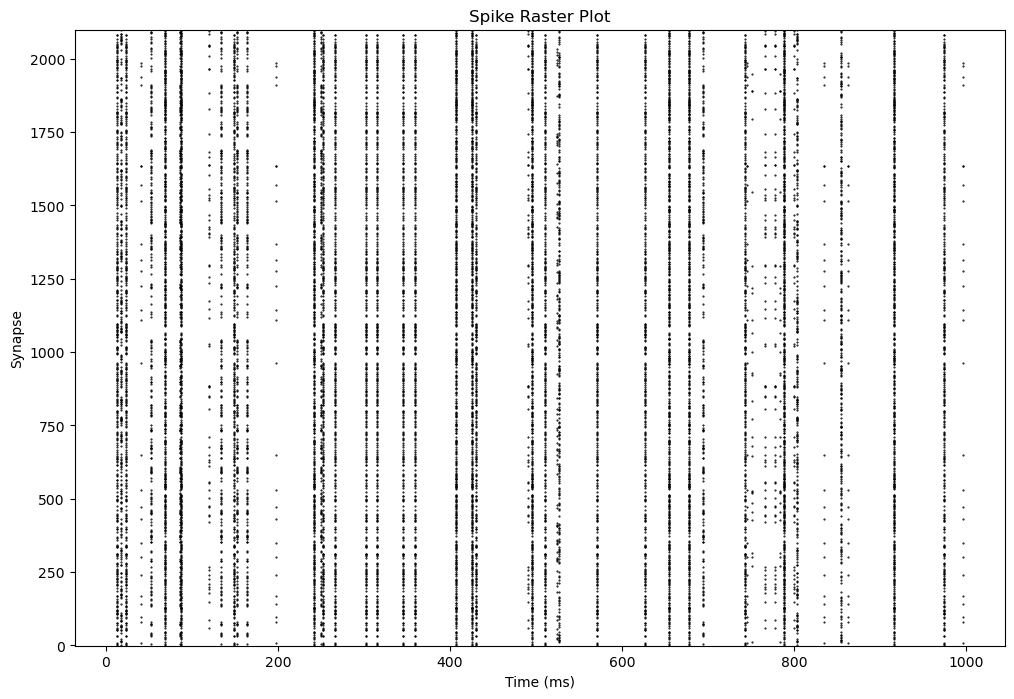

In [25]:
# Generate a spike raster plot for excitatory synapses
analyzer.plot_spike_raster(
    synapses=analyzer.synapses[analyzer.synapses['functional_group'] != -1],  # Filter for functional group 0
    synapse_types=['exc'],
    time_window=(0, 1000),  # First second of simulation
    save_path=os.path.join(sim_dir, 'spike_raster.png')
)

/tmp/ipykernel_1278673/3879478159.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_fgs))


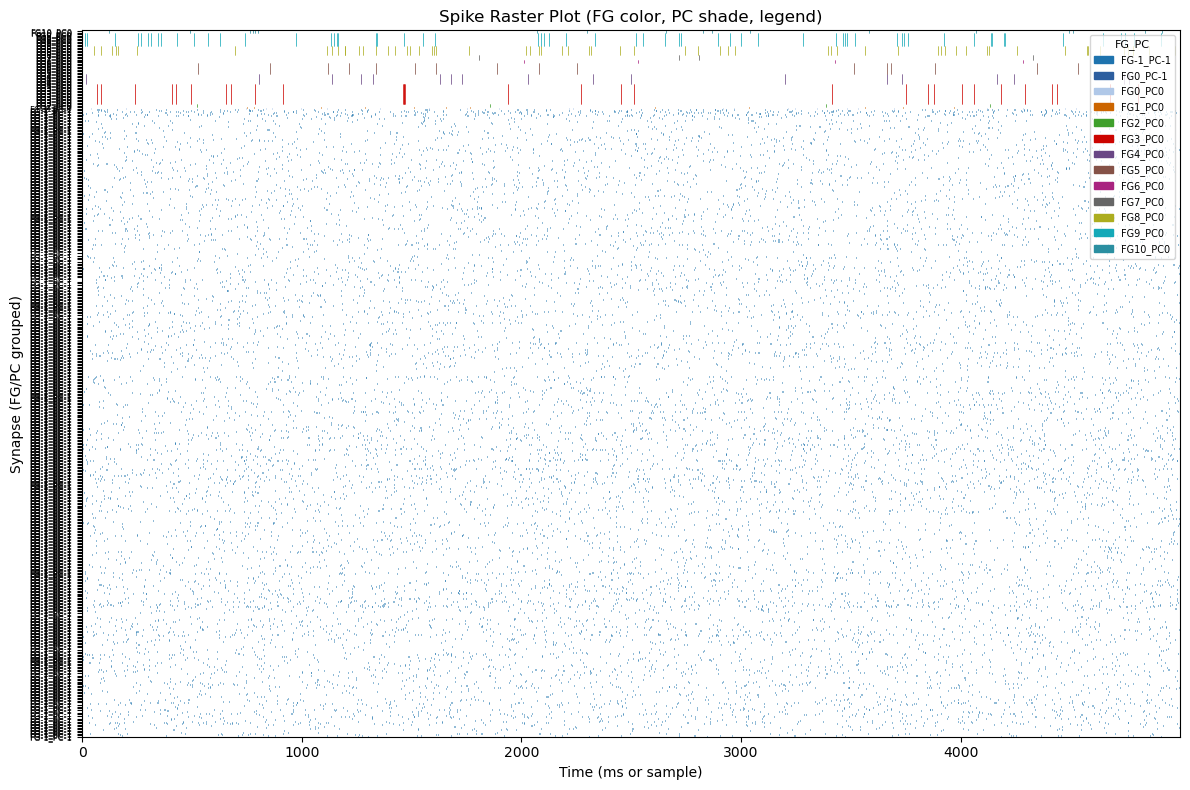

In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import colorsys
from matplotlib.patches import Patch

def get_shaded_color(base_rgb, pc_idx, n_pcs):
    """Return a lighter or darker shade for pc_idx out of n_pcs based on the base_rgb."""
    # Convert to HLS, vary lightness
    h, l, s = colorsys.rgb_to_hls(*base_rgb)
    # Lightness scale between 0.4 and 0.8
    l_new = 0.4 + 0.4 * (pc_idx / max(n_pcs-1, 1))
    return colorsys.hls_to_rgb(h, l_new, s)

def plot_spike_raster_fgpc_legend(
    synapses, 
    time_window=None, 
    figsize=(12, 8), 
    save_path=None,
    yticklabel_stride=30,
    show_y_labels=True,
    legend_loc='upper right'
):
    synapses_sorted = synapses.sort_values(['functional_group', 'presynaptic_cell'])
    synapses_sorted = synapses_sorted.reset_index(drop=True)

    # Get unique FGs and assign a base color per FG using tab20
    unique_fgs = synapses_sorted['functional_group'].unique()
    cmap = plt.cm.get_cmap('tab20', len(unique_fgs))
    fg_base_colors = {fg: cmap(i)[:3] for i, fg in enumerate(unique_fgs)}

    # Find all PC indices per FG for consistent shading
    fg_to_pcs = {
        fg: sorted(synapses_sorted[synapses_sorted['functional_group']==fg]['presynaptic_cell'].unique())
        for fg in unique_fgs
    }
    fg_pc_color = {}
    for fg, pcs in fg_to_pcs.items():
        n_pcs = len(pcs)
        for i, pc in enumerate(pcs):
            fg_pc_color[(fg, pc)] = get_shaded_color(fg_base_colors[fg], i, n_pcs)

    segments = []
    colors = []
    legend_labels = {}
    yticklabels = []
    yticks = []

    for idx, row in synapses_sorted.iterrows():
        # Robust spike train parsing
        spikes = row['spike_train']
        if isinstance(spikes, str):
            spikes = np.fromstring(spikes.replace('[', '').replace(']', ''), sep=' ')
        elif isinstance(spikes, (float, int)) or spikes is None or (isinstance(spikes, np.ndarray) and spikes.ndim == 0):
            continue
        else:
            spikes = np.array(spikes).flatten()
        if spikes.size == 0:
            continue
        if time_window is not None:
            spikes = spikes[(spikes >= time_window[0]) & (spikes <= time_window[1])]
        segs = [((spk, idx + 0.5), (spk, idx + 1.5)) for spk in spikes]
        segments.extend(segs)
        fg, pc = row['functional_group'], row['presynaptic_cell']
        color = fg_pc_color.get((fg, pc), (0,0,0))
        colors.extend([color]*len(segs))
        key = f'FG{int(fg)}_PC{int(pc)}'
        # Only keep first seen row for legend
        if key not in legend_labels:
            legend_labels[key] = color
        if show_y_labels and (idx % yticklabel_stride) == 0:
            yticklabels.append(key)
            yticks.append(idx + 1)

    fig, ax = plt.subplots(figsize=figsize)
    if segments:
        lc = LineCollection(segments, colors=colors, linewidths=0.7)
        ax.add_collection(lc)

    # X limits
    if time_window is not None:
        ax.set_xlim(time_window)
    else:
        try:
            all_spikes = np.hstack([
                np.fromstring(row['spike_train'].replace('[','').replace(']',''), sep=' ') if isinstance(row['spike_train'], str)
                else np.array(row['spike_train']).flatten()
                for _, row in synapses_sorted.iterrows()
                if not isinstance(row['spike_train'], (float, int)) and row['spike_train'] is not None
            ])
            ax.set_xlim(np.nanmin(all_spikes), np.nanmax(all_spikes))
        except:
            ax.set_xlim(0, 1000)

    ax.set_ylim(0.5, len(synapses_sorted) + 0.5)
    ax.set_ylabel("Synapse (FG/PC grouped)")
    ax.set_xlabel("Time (ms or sample)")

    if show_y_labels:
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticklabels, fontsize=6)
    else:
        ax.set_yticks([])
        ax.set_yticklabels([])

    ax.set_title("Spike Raster Plot (FG color, PC shade, legend)")

    # Legend
    patches = [Patch(color=color, label=label) for label, color in legend_labels.items()]
    # Optionally, only show legend for first N FG/PC combos
    if len(patches) > 25:
        patches = patches[:25]
    ax.legend(handles=patches, loc=legend_loc, title='FG_PC', fontsize=7, title_fontsize=8, frameon=True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()


plot_spike_raster_fgpc_legend(synapses, yticklabel_stride=40, show_y_labels=True)


In [27]:
synapses[synapses.presynaptic_cell==0] # view unique presynaptic cells

,name,modfile,P_0,initW,cell2cell_type,seg_id,gbar_ampa,gbar_nmda,gbar_gaba,spike_train,pc_mean_firing_rate,functional_group,presynaptic_cell
0,exc_tuft_0,pyr2pyr,0.354387,1.548931,PN2PN,2023,0.00159,0.001868,NaN,[2012 2533 3430 4282 4662],1.249588,6.0,0.0
1,exc_tuft_1,pyr2pyr,0.686850,1.683359,PN2PN,1638,0.00159,0.001868,NaN,[ 69 87 242 407 426 495 655 678 788 ...,6.068628,3.0,0.0
2,exc_tuft_2,pyr2pyr,0.379372,1.416896,PN2PN,2140,0.00159,0.001868,NaN,[ 18 803 1138 1268 1325 1631 1680 1729 2030 ...,3.960701,4.0,0.0
4,exc_tuft_4,pyr2pyr,0.990291,1.251326,PN2PN,1720,0.00159,0.001868,NaN,[ 13 23 149 253 266 302 315 345 360 ...,10.603298,9.0,0.0
5,exc_tuft_5,pyr2pyr,0.417642,1.626869,PN2PN,1736,0.00159,0.001868,NaN,[ 13 23 149 253 266 302 315 345 360 ...,10.603298,9.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2681,exc_tuft_2681,pyr2pyr,0.575314,1.674971,PN2PN,1828,0.00159,0.001868,NaN,[ 120 491 766 778 789 800 2072 2299 2659 ...,4.546756,10.0,0.0
2684,exc_tuft_2684,pyr2pyr,0.926095,1.476638,PN2PN,2149,0.00159,0.001868,NaN,[ 527 855 1120 1214 1337 1515 1613 1888 2078 ...,3.451116,5.0,0.0
2685,exc_tuft_2685,pyr2pyr,0.000000,1.524774,PN2PN,2028,0.00159,0.001868,NaN,[2012 2533 3430 4282 4662],1.249588,6.0,0.0
2686,exc_tuft_2686,pyr2pyr,0.254592,1.574474,PN2PN,1967,0.00159,0.001868,NaN,[ 69 87 242 407 426 495 655 678 788 ...,6.068628,3.0,0.0


In [28]:
# # Plot the spatial distribution of synapses belonging to clusters
# analyzer.plot_cluster_spatial_distribution(
#     synapse_type='exc',
#     save_path=os.path.join(sim_dir, 'spatial_distribution.png')
# )

In [29]:
# # Analyze correlations between spike trains
# analyzer.plot_correlation_matrix(
#     synapse_type='exc',
#     time_window=(0, 1000),
#     save_path=os.path.join(sim_dir, 'correlation_matrix.png')
# )

## Copy over the sim_dir to notebooks/AA_sim.ipynb then notebooks/AA_post_sim.ipynb for simulation and analysis.

In [30]:
os.path.abspath(sim_dir) # for copying over

'/home/drfrbc/Neural-Modeling/simulations/2025-06-06-14-01-baseline_clusters_dec_radius/complex'